In [1]:
import sys

if "google.colab" in sys.modules:
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    original_data = '/content/drive/My Drive/MS1/original_dataset'
    final_data = '/content/drive/My Drive/MS1/Final_Dataset'

    # Install required packages
    !pip install pymatgen torch_geometric mp_api

else:
    original_data = "original_dataset"
    final_data = "Final_Dataset"

In [2]:
"""# Get formation energy of all elements in the periodiic table
from mp_api.client import MPRester
import numpy as np
from pymatgen.core.periodic_table import Element


all_elements = [str(el) for el in Element]

API_KEY = ""

def get_formation(element, API_KEY):
    with MPRester(API_KEY) as mpr:
        results = mpr.materials.summary.search(
            elements=[element],
            num_elements=1,
            fields= ["energy_per_atom"]
        )
        forms_list = [result.energy_per_atom for result in results]
        avg_formation_energy = np.mean(forms_list)

    return avg_formation_energy

formation_energies = {element: get_formation(element, API_KEY) for element in all_elements}
print(formation_energies)"""

'# Get formation energy of all elements in the periodiic table\nfrom mp_api.client import MPRester\nimport numpy as np\nfrom pymatgen.core.periodic_table import Element\n\n\nall_elements = [str(el) for el in Element]\n\nAPI_KEY = ""\n\ndef get_formation(element, API_KEY):\n    with MPRester(API_KEY) as mpr:\n        results = mpr.materials.summary.search(\n            elements=[element],\n            num_elements=1,\n            fields= ["energy_per_atom"]\n        )\n        forms_list = [result.energy_per_atom for result in results]\n        avg_formation_energy = np.mean(forms_list)\n\n    return avg_formation_energy\n\nformation_energies = {element: get_formation(element, API_KEY) for element in all_elements}\nprint(formation_energies)'

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, NNConv, CGConv, global_max_pool, GCNConv

from pymatgen.core import Structure, PeriodicSite, DummySpecie, Composition, Element
from pymatgen.core.periodic_table import Element as PMGElement
from pymatgen.analysis.local_env import MinimumDistanceNN, CrystalNN, VoronoiNN
# from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

# import json
import config
import graphy_gnn
import graphy_cvae

API_KEY = "Not relevant right now"  # Replace with your Materials Project API key

/home/amutua/inverse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Prep

In [10]:
comb_df = pd.read_csv(f"{final_data}/combined/combined_data.csv")
train_graphs = torch.load(f"{final_data}/train_graphs.pt", weights_only=False)
test_graphs = torch.load(f"{final_data}/test_graphs.pt", weights_only=False)
val_graphs = torch.load(f"{final_data}/val_graphs.pt", weights_only=False)

# Sample row
sample_row = comb_df.iloc[0]

# Get defective structure
material = sample_row["dataset_material"]
id = sample_row["_id"]

# Get defective structure
defective_file_path = f"{original_data}/{material}/cifs/{id}.cif"
defective_structure = Structure.from_file(defective_file_path)

# Get reference structure
ref_file_path = f"{final_data}/ref_cifs/{material}.cif"
reference_structure = Structure.from_file(ref_file_path)

/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 32 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


In [11]:
# Test graphy_gnn functions
defects_structure = graphy_gnn.get_defects_structure(defective_structure, reference_structure)

nodes = graphy_gnn.get_nodes(defects_structure)
edges, edge_features = graphy_gnn.get_edges_and_features(reference_structure, defects_structure)
global_features = graphy_gnn.get_globals(reference_structure, defective_structure, defects_structure)

print("Nodes:", nodes)
print("Edges:", edges)
print("Edge Features:", edge_features)
print("Global Features:", global_features)


Nodes: [[np.float64(54.666088403202025), 1, -0.15000000000000002, 0.5099999999999998, 1, -0.10999999999999999, 6, 0.7, 1.262122611, 2.55, 14, 0.41, 4, 2, 5, 0.85, 0.27972325, 2.04, 13, 0.41, 3, 2, 0, 0.0, 0.0, 1.0, -2.3139048066251844], [np.float64(54.66608694544373), 1, -0.15000000000000002, 0.5099999999999998, 1, -0.10999999999999999, 6, 0.7, 1.262122611, 2.55, 14, 0.41, 4, 2, 5, 0.85, 0.27972325, 2.04, 13, 0.41, 3, 2, 0, 0.0, 0.0, 1.0, -2.3139048066251844], [np.float64(54.66608694544392), -7, -0.65, -3.04, -15, -0.63, 0, 0.0, 0.0, 0.0, 0, 0.0, 0, 0, 7, 0.65, -0.07, 3.04, 15, 0.63, 5, 2, -2, 3, 1.0, 0.0, 7.233842272742187]]
Edges: [[0, 0, 1], [1, 2, 2]]
Edge Features: [[13.98860945246643, np.float64(6.647261259887691), 0.6959705358369901, 5.3541554541231315, -4.627809613250369, 0.0, 16, 1.1437877406162718, 0.012099999999999998, 4.420401671366696e-06, np.float64(1.0), 0, 1, 0], [15.134745243136157, np.float64(5.241317743503728), 0.752993840625424, -16.738422405266594, 4.91993746611700

In [12]:
# Create graph representation of the structures
def graphy(row, reference_structure):
    material = row["dataset_material"]
    id = row["_id"]
    defective_structure = Structure.from_file(f"{original_data}/{material}/cifs/{id}.cif")

    defects_structure = graphy_gnn.get_defects_structure(defective_structure, reference_structure)

    nodes = graphy_gnn.get_nodes(defects_structure)
    edges, edge_features = graphy_gnn.get_edges_and_features(reference_structure, defects_structure)
    global_features = graphy_gnn.get_globals(reference_structure, defective_structure, defects_structure)

    target = row["band_gap_value"]

    the_data = Data(
        x=torch.tensor(nodes, dtype=torch.float),
        edge_index=torch.tensor(edges, dtype=torch.long),
        edge_attr=torch.tensor(edge_features, dtype=torch.float),
        u=torch.tensor(global_features, dtype=torch.float).unsqueeze(0),
        y=torch.tensor(target, dtype=torch.float).unsqueeze(0)
    )
    return the_data

def fast_grapy(dataset):
    graph_list = []
    unique_dataset_materials = dataset["dataset_material"].unique()

    all_mat = len(unique_dataset_materials)

    for i in unique_dataset_materials:
        subset = dataset[dataset["dataset_material"] == i].reset_index(drop=True)
        all_rows = len(subset)

        pristine_structure = Structure.from_file(f"{final_data}/ref_cifs/{i}.cif")
        
        # Go through every row in the subset
        for index, row in subset.iterrows():
            data = graphy(row, pristine_structure)

            # Track progress
            if index % 10 == 0:  # Print progress every 10 rows
                print(f"material {i} ({index+1}/{all_rows}) - {((index+1)/all_rows)*100:.2f}% complete")
            
            # Put all graphs together in a list
            graph_list.append(data)
            
    return graph_list

In [13]:
if not os.path.exists(f"{final_data}/train_graphs.pt"):
    # Split the data
    train_set, test_set = train_test_split(comb_df, test_size=0.2, stratify=comb_df['strata'], random_state=42)
    test_set, val_set = train_test_split(test_set, test_size=0.5, random_state=42)

    # Create graphs for each set
    train_graphs = fast_grapy(train_set)
    val_graphs = fast_grapy(val_set)
    test_graphs = fast_grapy(test_set)

    # Save graphs
    torch.save(train_graphs, f"{final_data}/train_graphs.pt")
    torch.save(val_graphs, f"{final_data}/val_graphs.pt")
    torch.save(test_graphs, f"{final_data}/test_graphs.pt")

else:
    train_graphs = torch.load(f"{final_data}/train_graphs.pt", weights_only=False)
    val_graphs = torch.load(f"{final_data}/val_graphs.pt", weights_only=False)
    test_graphs = torch.load(f"{final_data}/test_graphs.pt", weights_only=False)

In [14]:
# Find the graph where the edge features has shape 0 and remove them

def remove_1_defect_graphs(graphs):
    unwanted = []
    for i, data in enumerate(graphs):
        if data.edge_attr.shape[0] == 0:
            unwanted.append(i)

    new_graphs = [data for i, data in enumerate(graphs) if i not in unwanted]
    return new_graphs

new_train_graphs = remove_1_defect_graphs(train_graphs)
new_val_graphs = remove_1_defect_graphs(val_graphs)
new_test_graphs = remove_1_defect_graphs(test_graphs)

In [15]:
# Create data loaders
train_loader = DataLoader(new_train_graphs, batch_size=1, shuffle=True)
val_loader = DataLoader(new_val_graphs, batch_size=1, shuffle=False)
test_loader = DataLoader(new_test_graphs, batch_size=1, shuffle=False)

In [16]:
# Use data size to determine model architecture
NODE_DIM =train_graphs[0].x.shape[1] # 27
EDGE_DIM =train_graphs[0].edge_attr.shape[1] # 14
HIDDEN_DIM = 128
EMBED_DIM = 64
U_DIM =train_graphs[0].u.shape[1] # 14

# The GNN Model

In [11]:
# Train model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            loss = loss_fn(out, data.y)

            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def train(model, train_loader, val_loader, epochs, optimizer, loss_fn):
    train_losses = []
    val_losses = []

    # Learning rate scheduler to help convergence
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()

            out = model(data)
            loss = loss_fn(out, data.y)

            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.num_graphs
        train_loss = total_loss / len(train_loader.dataset)
        # train_loss = train(the_model, train_loader, optimizer, loss_fn)
        val_loss = evaluate(model, val_loader, loss_fn)
        scheduler.step()

        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    # Test model
    test_loss = evaluate(model, test_loader, loss_fn)
    print(f'Test Loss: {test_loss:.4f}')

    return train_losses, val_losses

def predict(model, loader, actuals=False):
    model.eval()
    if actuals:
        predictions = []
        actual = []
        with torch.no_grad():
            for data in loader:
                data = data.to(device)

                out = model(data)
                predictions.append(out.cpu().numpy())
                actual.append(data.y.cpu().numpy())

        predictions = np.concatenate(predictions, axis=0).flatten()
        actual = np.concatenate(actual, axis=0).flatten()
        return predictions, actual
    else:
        predictions = []
        with torch.no_grad():
            for data in loader:
                data = data.to(device)

                out = model(data)
                predictions.append(out.cpu().numpy())

        predictions = np.concatenate(predictions, axis=0).flatten()
        return predictions

# Informative Graphs
def get_graphs(train_losses, val_losses, the_model):
    fig, axs = plt.subplots(3, 1, figsize=(10, 10))

    axs[0].plot(train_losses, label='Train Loss')
    axs[0].plot(val_losses, label='Validation Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training  and Validation Loss')
    axs[0].legend()

    # model values
    predicted_values, actual_values = predict(the_model, test_loader, actuals=True)


    axs[1].scatter(actual_values, predicted_values )
    axs[1].plot(actual_values, actual_values, c="black")
    axs[1].set_xlabel('Actual Band Gaps(eV)')
    axs[1].set_ylabel('Predicted Band Gaps(eV)')
    axs[1].set_title('Actual vs Predicted Band Gap Values')

    axs[2].plot(actual_values[100:150], label='Actual Values', marker='o')
    axs[2].plot(predicted_values[100:150], label='Predicted Values', marker='o')
    axs[2].set_xlabel('Samples')
    axs[2].set_ylabel('Band gap(eV)')
    axs[2].set_title('Actual vs Predicted Band Gap Values')
    axs[2].legend()

    plt.show()


class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        ey_t = input-target
        return torch.mean(torch.log(torch.cosh(ey_t + 1e-12)))


class RelativeMSELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        return torch.mean(((y_pred-y_true)/ (y_true + 1e-8)) ** 2)


class SMAPELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        numerator = torch.abs(y_pred - y_true)
        denominator = (torch.abs(y_true) + torch.abs(y_pred))/2.0 + 1e-8
        return torch.mean(numerator/denominator)

# Loss function
# loss_fn = nn.MSELoss()
loss_fn = LogCoshLoss()
# loss_fn = RelativeMSELoss()
# loss_fn = SMAPELoss()

## Model 1

In [49]:
# Using CGCNN
from torch_geometric.nn import CGConv

sample_x = torch.randn((4, NODE_DIM))  # Example node features
sample_edge_index = torch.tensor([[0,0,0,1,1,1,2,2,2,3,3,3], [1,2,3,0,2,3,0,1,3,0,1,2]], dtype=torch.long)
sample_edge_attr = torch.randn((12, EDGE_DIM))
print(f"x:{sample_x.shape}, edge_index: {sample_edge_index.shape}, edge_attr: {sample_edge_attr.shape}")

# For the edges
edge_nn = nn.Sequential(
    nn.Linear(EDGE_DIM, 64),
    nn.ReLU(),
    nn.Linear(64, NODE_DIM * HIDDEN_DIM)
)

layer0 = NNConv(NODE_DIM, HIDDEN_DIM, edge_nn, aggr='mean')
layer1 = CGConv(HIDDEN_DIM, EDGE_DIM, aggr='mean', batch_norm=True)
layer2 = CGConv(HIDDEN_DIM, EDGE_DIM, aggr='mean', batch_norm=True)
layer3 = CGConv(HIDDEN_DIM, EDGE_DIM, aggr='mean', batch_norm=True)

out0 = F.relu(layer0(sample_x, sample_edge_index, sample_edge_attr))
print(f"out0: {out0.shape}")

out1 = F.relu(layer1(out0, sample_edge_index, sample_edge_attr))
print(f"out1: {out1.shape}")

out2 = F.relu(layer2(out1, sample_edge_index, sample_edge_attr))
print(f"out2: {out2.shape}")

out3 = F.relu(layer3(out2, sample_edge_index, sample_edge_attr))
print(f"out3: {out3.shape}")


x:torch.Size([4, 27]), edge_index: torch.Size([2, 12]), edge_attr: torch.Size([12, 14])
out0: torch.Size([4, 128])
out1: torch.Size([4, 128])
out2: torch.Size([4, 128])
out3: torch.Size([4, 128])


Epoch 001, Train Loss: 0.0199, Val Loss: 0.0330
Epoch 002, Train Loss: 0.0099, Val Loss: 0.0075
Epoch 003, Train Loss: 0.0084, Val Loss: 0.0075
Epoch 004, Train Loss: 0.0080, Val Loss: 0.0355
Epoch 005, Train Loss: 0.0081, Val Loss: 0.0071
Epoch 006, Train Loss: 0.0087, Val Loss: 0.0079
Epoch 007, Train Loss: 0.0085, Val Loss: 0.0109
Epoch 008, Train Loss: 0.0084, Val Loss: 0.0070
Epoch 009, Train Loss: 0.0073, Val Loss: 0.0069
Epoch 010, Train Loss: 0.0074, Val Loss: 0.0085
Epoch 011, Train Loss: 0.0076, Val Loss: 0.0079
Epoch 012, Train Loss: 0.0085, Val Loss: 0.0081
Epoch 013, Train Loss: 0.0083, Val Loss: 0.0072
Epoch 014, Train Loss: 0.0081, Val Loss: 0.0099
Epoch 015, Train Loss: 0.0085, Val Loss: 0.0078
Epoch 016, Train Loss: 0.0082, Val Loss: 0.0073
Epoch 017, Train Loss: 0.0080, Val Loss: 0.0073
Epoch 018, Train Loss: 0.0083, Val Loss: 0.0073
Epoch 019, Train Loss: 0.0083, Val Loss: 0.0087
Epoch 020, Train Loss: 0.0096, Val Loss: 0.0091
Test Loss: 0.0098


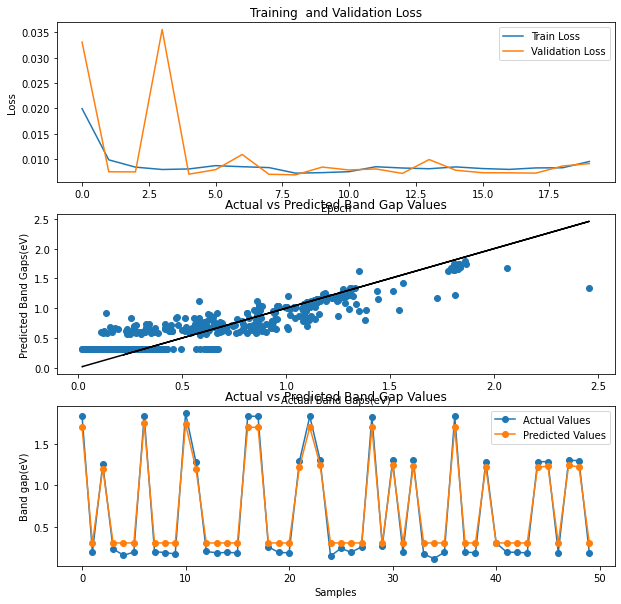

In [59]:
class GNNModelCG(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, u_dim=U_DIM):
        super().__init__()
        # For the edges
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, 64),
            nn.ReLU(),
            nn.Linear(64, node_dim * hidden_dim)
        )

        self.conv0 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')
        self.conv1 = CGConv(hidden_dim, edge_dim, aggr='mean') # , batch_norm=True)
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean') # , batch_norm=True)
        self.conv3 = CGConv(hidden_dim, edge_dim, aggr='mean') # , batch_norm=True)

        self.global_embed = nn.Linear(u_dim, embed_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )
        # print("New forward pass")
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        x = F.relu(self.conv0(x, edge_index, edge_attr))
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.relu(self.conv3(x, edge_index, edge_attr))
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        # x = F.relu(self.conv2(x, edge_index, edge_attr))
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        x = global_mean_pool(x, batch)
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        u = self.global_embed(u)
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        x = torch.cat([x, u], dim=1)
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        the_return = self.fc(x)
        return the_return

# Use the CGConv-only model if you want a simpler graph architecture.
GNN_model_cg = GNNModelCG().to(device)

# optimizer
optimizer = torch.optim.Adam(GNN_model_cg.parameters(), lr=0.001)

# Train the model
train_losses, val_losses = train(GNN_model_cg, train_loader, val_loader, epochs=20, optimizer=optimizer, loss_fn=loss_fn)
get_graphs(train_losses, val_losses, GNN_model_cg)

## Model 2

Epoch 001, Train Loss: 0.1043, Val Loss: 0.0477
Epoch 002, Train Loss: 0.0289, Val Loss: 0.0271
Epoch 003, Train Loss: 0.0217, Val Loss: 0.0208
Epoch 004, Train Loss: 0.0165, Val Loss: 0.0138
Epoch 005, Train Loss: 0.0153, Val Loss: 0.0128
Epoch 006, Train Loss: 0.0129, Val Loss: 0.0150
Epoch 007, Train Loss: 0.0115, Val Loss: 0.0116
Epoch 008, Train Loss: 0.0110, Val Loss: 0.0090
Epoch 009, Train Loss: 0.0101, Val Loss: 0.0120
Epoch 010, Train Loss: 0.0091, Val Loss: 0.0118
Epoch 011, Train Loss: 0.0090, Val Loss: 0.0092
Epoch 012, Train Loss: 0.0083, Val Loss: 0.0156
Epoch 013, Train Loss: 0.0084, Val Loss: 0.0072
Epoch 014, Train Loss: 0.0079, Val Loss: 0.0085
Epoch 015, Train Loss: 0.0076, Val Loss: 0.0104
Epoch 016, Train Loss: 0.0073, Val Loss: 0.0069
Epoch 017, Train Loss: 0.0072, Val Loss: 0.0081
Epoch 018, Train Loss: 0.0070, Val Loss: 0.0073
Epoch 019, Train Loss: 0.0068, Val Loss: 0.0068
Epoch 020, Train Loss: 0.0068, Val Loss: 0.0069
Test Loss: 0.0073


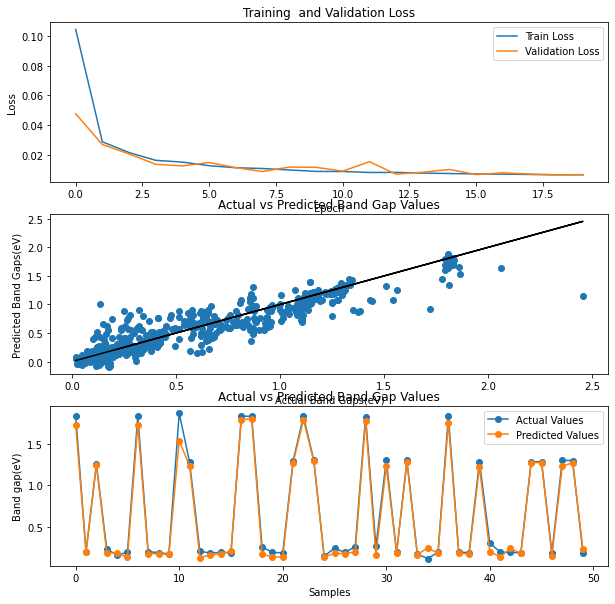

In [ ]:
class Model2(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, u_dim=U_DIM):
        super().__init__()

        # For the edges
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, 64),
            nn.ReLU(),
            nn.Linear(64, node_dim * hidden_dim)
        )

        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')

        # self.conv1 = CGConv(hidden_dim, hidden_dim, aggr='mean')
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')

        self.global_embed = nn.Linear(u_dim, embed_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)

        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        the_return = self.fc(x)
        return the_return

# Use the CGConv-only model if you want a simpler graph architecture.
model_2 = Model2().to(device)

# optimizer
optimizer = torch.optim.Adam(model_2.parameters(), lr=0.00001)

# Train this model
train_losses, val_losses = train(model_2, train_loader, val_loader, epochs=20, optimizer=optimizer, loss_fn=loss_fn)
get_graphs(train_losses, val_losses, model_2)

## Model 3

Epoch 001, Train Loss: 0.0429, Val Loss: 0.0141
Epoch 002, Train Loss: 0.0229, Val Loss: 0.0209
Epoch 003, Train Loss: 0.0205, Val Loss: 0.0139
Epoch 004, Train Loss: 0.0206, Val Loss: 0.0167
Epoch 005, Train Loss: 0.0193, Val Loss: 0.0213
Epoch 006, Train Loss: 0.0183, Val Loss: 0.0210
Epoch 007, Train Loss: 0.0185, Val Loss: 0.0105
Epoch 008, Train Loss: 0.0185, Val Loss: 0.0100
Epoch 009, Train Loss: 0.0180, Val Loss: 0.0130
Epoch 010, Train Loss: 0.0185, Val Loss: 0.0367
Epoch 011, Train Loss: 0.0183, Val Loss: 0.0143
Epoch 012, Train Loss: 0.0180, Val Loss: 0.0094
Epoch 013, Train Loss: 0.0180, Val Loss: 0.0146
Epoch 014, Train Loss: 0.0179, Val Loss: 0.0138
Epoch 015, Train Loss: 0.0179, Val Loss: 0.0216
Epoch 016, Train Loss: 0.0182, Val Loss: 0.0120
Epoch 017, Train Loss: 0.0180, Val Loss: 0.0182
Epoch 018, Train Loss: 0.0184, Val Loss: 0.0356
Epoch 019, Train Loss: 0.0179, Val Loss: 0.0247
Epoch 020, Train Loss: 0.0173, Val Loss: 0.0141
Test Loss: 0.0156


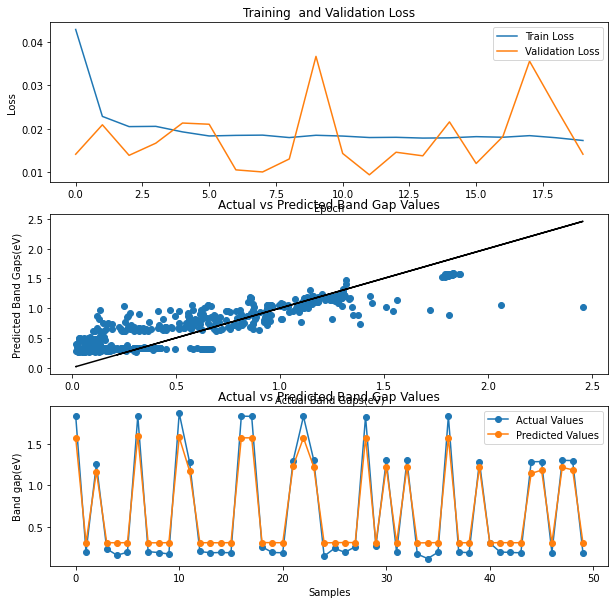

In [ ]:
class GNNModel(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, global_dim=U_DIM):
        super().__init__()

        # Edge network for NNConv: maps each edge_attr to a weight matrix
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, node_dim * hidden_dim),
        )

        # First message-passing layer
        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_mlp, aggr='mean')

        # Second message-passing layer using CGConv
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')
        # self.conv3 = CGConv(hidden_dim, edge_dim, aggr='mean')

        # Embed the graph-level global features
        self.global_embed = nn.Linear(global_dim, embed_dim)

        # Final MLP head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 128),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.Dropout(0.2),
            # NO ReLU here - allow both positive and negative outputs
            nn.Linear(32, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        # x = F.relu(self.conv3(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)
        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        return self.fc(x)

GNN_model = GNNModel().to(device)

# optimizer with L2 regularization to prevent overfitting
optimizer = torch.optim.Adam(GNN_model.parameters(), lr=0.001, weight_decay=1e-4)

train_losses, val_losses = train(GNN_model, train_loader, val_loader, epochs=20, optimizer=optimizer, loss_fn=loss_fn)
get_graphs(train_losses, val_losses, GNN_model)